In [47]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
import pandas as pd
insurance_data=pd.read_csv("archive.zip")

In [3]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [19]:
x=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

x["sex"]=x["sex"].map({"female":1, "male":0})
x["smoker"]=x["smoker"].map({"yes":1, "no":0})

x=pd.get_dummies(x, columns=["region"], drop_first=True, dtype=int)

x["age_smoker"]=x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]

x

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.90
1,18,0,33.770,1,0,0,1,0,0,0.00
2,28,0,33.000,3,0,0,1,0,0,0.00
3,33,0,22.705,0,0,1,0,0,0,0.00
4,32,0,28.880,0,0,1,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1,0,0,0,0.00
1334,18,1,31.920,0,0,0,0,0,0,0.00
1335,18,1,36.850,0,0,0,1,0,0,0.00
1336,21,1,25.800,0,0,0,0,1,0,0.00


In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import Lasso
lasso_model=Lasso(alpha=0.5)
lasso_model.fit(x_train,y_train)

y_pred=lasso_model.predict(x_test)

mse=mean_squared_error(y_test, y_pred)
print("MSE:",mse)

MSE: 20918648.889825605


In [31]:
alphas=[0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 1000]
mses=[]
for a in alphas:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(x_train,y_train)
    
    y_pred=lasso_model.predict(x_test)
    
    mse=mean_squared_error(y_test, y_pred)
    print(f"mse for {a} is {mse}")
    mses.append(mse)    

mse for 0.0001 is 20922607.131011523
mse for 0.001 is 20922599.87103596
mse for 0.01 is 20922527.32662988
mse for 0.1 is 20921803.698431373
mse for 1 is 20914832.63508914
mse for 5 is 20890881.000633497
mse for 10 is 20872844.794796687
mse for 50 is 21196929.86960891
mse for 100 is 22423172.686023246
mse for 1000 is 23484993.605532043


<Axes: >

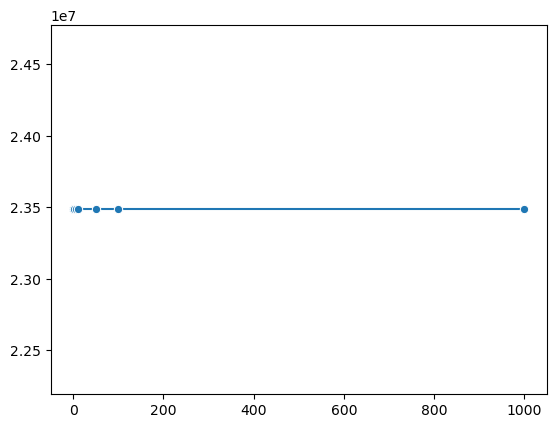

In [35]:
import seaborn as sns
sns.lineplot(x=alphas, y=mse, marker="o")

In [48]:
from sklearn.linear_model import LassoCV
a=[0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 1000]

lasso_cv_model=LassoCV(alphas=a, cv=5, max_iter=1000, random_state=42)
lasso_cv_model.fit(x_train,y_train)

print("best alpha value:", lasso_cv_model.alpha_)

y_pred=lasso_cv_model.predict(x_test)
    
mse=mean_squared_error(y_test, y_pred)
print("mse:",mse)

r2_score=r2_score(y_pred, y_test)
print("r2 value:", r2_score)

best alpha value: 0.0001
mse: 20922607.131011523
r2 value: 0.8508509760094696
